In [1]:
from PIL import Image, ImageOps
from pillow_heif import register_heif_opener
import numpy as np
import sys 
import cv2
import matplotlib.pyplot as plt

In [19]:
register_heif_opener()
image = Image.open("Gold_Dots/NorahJones-ComeAwayWithMe.HEIC") 
image = ImageOps.exif_transpose(image)  # Correct orientation based on EXIF data
image = image.convert("RGB")  # Convert to RGB mode

rgb_array_original = np.array(image)  # Convert to NumPy array
bgr_array_original = rgb_array_original[..., ::-1]  # Convert RGB to BGR by reversing the last dimension

In [20]:
scale_factor = 1500 / max(bgr_array_original.shape[:2])  # scale so long edge = 1500px
small = cv2.resize(bgr_array_original, None, fx=scale_factor, fy=scale_factor, interpolation=cv2.INTER_AREA)
rgb_array = np.array(small)[..., ::-1]  # Convert BGR back to RGB for displaying with matplotlib
bgr_array = np.array(small)  # Keep BGR for OpenCV processing

In [21]:
gray = cv2.cvtColor(bgr_array, cv2.COLOR_BGR2GRAY)

blurred = cv2.GaussianBlur(gray, (5, 5), 0)
#Blurs the image to reduce noise and improve edge detection.
edges = cv2.Canny(blurred, 40, 120)



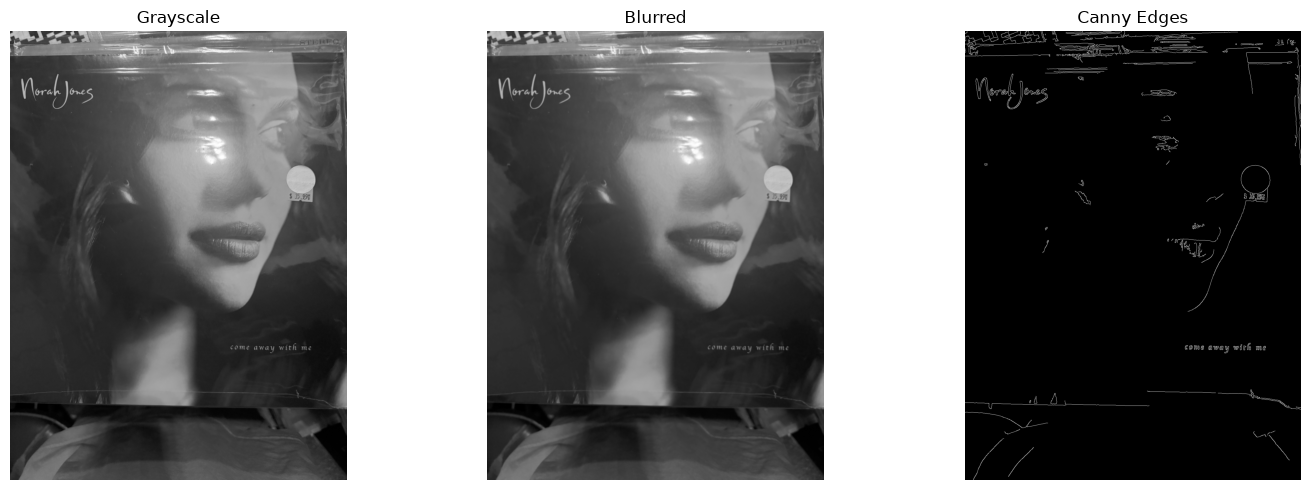

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Grayscale")
axes[0].axis("off")
 
axes[1].imshow(blurred, cmap="gray")
axes[1].set_title("Blurred")
axes[1].axis("off")
 
axes[2].imshow(edges, cmap="gray")
axes[2].set_title("Canny Edges")
axes[2].axis("off")
 
plt.tight_layout()
plt.show()

In [23]:
# threshold_pairs = [(30, 100), (50, 150), (30, 150), (20, 80), (40, 120)]

# fig, axes = plt.subplots(1, len(threshold_pairs), figsize=(20, 5))
# for ax, (lower, upper) in zip(axes, threshold_pairs):
#     test_edges = cv2.Canny(blurred, lower, upper)
#     ax.imshow(test_edges, cmap="gray")
#     ax.set_title(f"low={lower}, high={upper}")
#     ax.axis("off")
# plt.tight_layout()
# plt.show()

# print("edges dtype:", edges.dtype)
# print("edges shape:", edges.shape)
# print("non-zero pixel count:", np.count_nonzero(edges))
# print("max value:", edges.max())
# print("gray min/max:", gray.min(), gray.max())
# print("blurred min/max:", blurred.min(), blurred.max())

# plt.imshow(gray, cmap="gray")
# plt.title("Grayscale input to Canny")
# plt.axis("off")
# plt.show()
# plt.imshow(cv2.cvtColor(bgr_array, cv2.COLOR_BGR2RGB))
# plt.axis("off")
# plt.show()

# plt.figure(figsize=(10,10))
# plt.imshow(edges, cmap="gray")
# plt.axis("off")
# plt.show()

In [24]:
def line_score(line, width):
    x1, y1, x2, y2 = line
    length = np.hypot(x2 - x1, y2 - y1)
    width_span = abs(x2 - x1)  # horizontal reach, ignoring how much it's tilted
    return length * (width_span / width)  # penalize lines that don't span much of the frame

In [25]:
def merge_collinear_segments(segments, y_tolerance=20):
    """
    Group line segments that likely belong to the same physical edge (e.g.
    one edge broken into several pieces by glare) and merge each group into
    a single segment spanning its extreme left/right endpoints.

    Args:
        segments: list of (x1, y1, x2, y2) tuples, already filtered to be
                  roughly the same angle as each other
        y_tolerance: max difference in average y-position for two segments
                     to be considered part of the same edge

    Returns:
        list of merged (x1, y1, x2, y2) segments, one per cluster
    """
    if not segments:
        return []

    # sort by average y so segments belonging to the same edge end up adjacent
    segments = sorted(segments, key=lambda s: (s[1] + s[3]) / 2)

    clusters = []
    current_cluster = [segments[0]]
    current_y = (segments[0][1] + segments[0][3]) / 2

    for seg in segments[1:]:
        seg_y = (seg[1] + seg[3]) / 2
        if abs(seg_y - current_y) <= y_tolerance:
            current_cluster.append(seg)
        else:
            clusters.append(current_cluster)
            current_cluster = [seg]
        current_y = seg_y
    clusters.append(current_cluster)

    merged = []
    for cluster in clusters:
        # bridge glare-induced gaps by taking the overall leftmost and
        # rightmost endpoints across every fragment in the cluster
        all_points = [(s[0], s[1]) for s in cluster] + [(s[2], s[3]) for s in cluster]
        left_point = min(all_points, key=lambda p: p[0])
        right_point = max(all_points, key=lambda p: p[0])
        merged.append((left_point[0], left_point[1], right_point[0], right_point[1]))

    return merged


def find_matching_bottom_line(bottom_candidates, top_line, angle_tolerance=5):
    """
    Pick (or reconstruct) the bottom edge using the already-detected top edge
    as a prior: an album cover is roughly rectangular, so its bottom edge
    should have close to the same angle -- and, after merging any
    glare-fragmented pieces, close to the same length -- as the top edge.
    This is more robust than just grabbing the single longest bottom-half
    line, since the bottom edge is often the one broken up by glare and a
    stray line (hand, shadow, reflection) can otherwise get picked instead.

    Args:
        bottom_candidates: list of (x1, y1, x2, y2) roughly-horizontal lines
                            detected in the bottom half of the frame
        top_line: the already-resolved (x1, y1, x2, y2) top edge
        angle_tolerance: degrees of allowed deviation from the top edge's angle

    Returns:
        best-matching (possibly merged) bottom line, or None if nothing
        in bottom_candidates has a close enough angle to the top edge
    """
    if not bottom_candidates or top_line is None:
        return None

    tx1, ty1, tx2, ty2 = top_line
    top_angle = np.degrees(np.arctan2(ty2 - ty1, tx2 - tx1))
    top_length = np.hypot(tx2 - tx1, ty2 - ty1)

    # keep only candidates whose angle roughly matches the top edge
    matching = []
    for seg in bottom_candidates:
        x1, y1, x2, y2 = seg
        angle = np.degrees(np.arctan2(y2 - y1, x2 - x1))
        # normalize the angle difference (handles e.g. -179 vs 179 wraparound)
        angle_diff = abs((angle - top_angle + 180) % 360 - 180)
        if angle_diff <= angle_tolerance:
            matching.append(seg)

    if not matching:
        return None

    # bridge glare-fragmented pieces of what may be the same physical edge
    merged_candidates = merge_collinear_segments(matching)

    # prefer whichever merged candidate has length closest to the top edge's
    best = min(
        merged_candidates,
        key=lambda seg: abs(np.hypot(seg[2] - seg[0], seg[3] - seg[1]) - top_length)
    )
    return best

In [26]:
def detect_top_bottom_lines(edges: np.ndarray, image_shape: tuple):
    """
    Run Hough line detection on a Canny edge map and isolate the best
    candidate lines for the album cover's top and bottom edges.
 
    Args:
        edges: binary edge map from cv2.Canny
        image_shape: (height, width) of the original image, used to split
                     candidate lines into "top half" vs "bottom half" and
                     to filter by minimum line length
 
    Returns:
        top_line, bottom_line -- each a tuple (x1, y1, x2, y2), or None if
        no suitable candidate was found for that edge
    """
    height, width = image_shape[:2]
 
    # HoughLinesP returns line segments directly (as opposed to HoughLines,
    # which returns infinite lines in polar form) -- segments are easier to
    # reason about here since we care about actual endpoints for corners.
    #
    # Tunable params:
    #   threshold        -- min votes for a line to be returned
    #   minLineLength    -- discard segments shorter than this (filters noise)
    #   maxLineGap       -- max gap allowed to still treat two segments as one line
    lines = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi / 180,
        threshold=150,
        minLineLength=width * 0.3,   # require lines to span a meaningful chunk of the frame
        maxLineGap=150
    )

    # print(f"Total raw lines found: {0 if lines is None else len(lines)}")

    # # draw ALL of them, unfiltered, to see what Hough is picking up
    # vis = bgr_array.copy()
    # if lines is not None:
    #     for line in lines:
    #         x1, y1, x2, y2 = line[0]
    #         cv2.line(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)

    # plt.figure(figsize=(8, 8))
    # plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    # plt.axis("off")
    # plt.show()
 
    if lines is None:
        return None, None
 
    horizontal_lines = []
    for line in lines:
        x1, y1, x2, y2 = line
        
        # Angle relative to horizontal -- near 0 or near 180 degrees means "roughly horizontal"
        angle = np.degrees(np.arctan2(y2 - y1, x2 - x1))
        if abs(angle) < 10 or abs(angle) > 170:  # tolerance for slight tilt
            horizontal_lines.append((x1, y1, x2, y2))
 
    if not horizontal_lines:
        return None, None
 
    # Top candidates are restricted to the top 20% of the frame -- the album
    # cover's top edge should start close to the top of the photo, and this
    # keeps interior horizontal lines (text, artwork detail) from being
    # mistaken for the top edge. Bottom candidates keep the looser "bottom
    # half of the frame" rule.
    top_candidates = [l for l in horizontal_lines if ((l[1] + l[3]) / 2) < height * 0.2]
    bottom_candidates = [l for l in horizontal_lines if ((l[1] + l[3]) / 2) >= height / 2]
 
    def longest(lines_list):
        if not lines_list:
            return None
        return max(lines_list, key=lambda l: np.hypot(l[2] - l[0], l[3] - l[1]))
 
    top_line = longest(top_candidates)

    # Top edge tends to be detected reliably; use it as a prior for the
    # bottom edge, which is more often broken up by glare. This filters out
    # candidates (e.g. a hand, a shadow) whose angle doesn't match the top
    # edge or that aren't far enough from it, and bridges any
    # glare-fragmented pieces of the real bottom edge into one segment
    # before picking the best length match.
    bottom_line = find_matching_bottom_line(bottom_candidates, top_line, height)
    if bottom_line is None:
        # fall back to the simple "longest candidate" approach if nothing
        # matched the top edge's angle/separation closely enough
        bottom_line = longest(bottom_candidates)
 
    return top_line, bottom_line

In [27]:
def visualize_lines(image_bgr: np.ndarray, top_line, bottom_line):
    """Draw the detected top/bottom lines on a copy of the image for a sanity check."""
    vis = image_bgr.copy()
    if top_line is not None:
        x1, y1, x2, y2 = top_line
        cv2.line(vis, (x1, y1), (x2, y2), (0, 255, 0), 3)  # green
    if bottom_line is not None:
        x1, y1, x2, y2 = bottom_line
        cv2.line(vis, (x1, y1), (x2, y2), (0, 0, 255), 3)  # red
 
    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title("Detected top (green) / bottom (red) lines")
    plt.axis("off")
    plt.show()
 

In [28]:
def resolve_corners(top_line, bottom_line, image_shape):
    """
    Given top and bottom edge line segments, resolve the 4 corner points of
    the album cover. Left/right endpoints of each line are used directly if
    they terminate within the frame; if a line's detected endpoint sits at
    (or very near) the image border, that's treated as evidence the true
    corner is off-frame, and the border coordinate is used as-is (since it's
    already the frame edge).
 
    Args:
        top_line: (x1, y1, x2, y2) or None
        bottom_line: (x1, y1, x2, y2) or None
        image_shape: (height, width) of the original image
 
    Returns:
        A 4x2 numpy array of corners in order:
        [top-left, top-right, bottom-right, bottom-left]
        or None if either line is missing (can't proceed without both anchors)
    """
    if top_line is None or bottom_line is None:
        return None
 
    height, width = image_shape[:2]
 
    def sorted_endpoints(line):
        x1, y1, x2, y2 = line
        # Return left point first, right point second, regardless of detection order
        if x1 <= x2:
            return (x1, y1), (x2, y2)
        else:
            return (x2, y2), (x1, y1)
 
    top_left, top_right = sorted_endpoints(top_line)
    bottom_left, bottom_right = sorted_endpoints(bottom_line)
 
    corners = np.array([top_left, top_right, bottom_right, bottom_left], dtype="float32")
    return corners

In [29]:
def warp_to_rectangle(image_bgr: np.ndarray, corners: np.ndarray, output_size=(600, 600)):
    """
    Apply a perspective transform to flatten the region defined by `corners`
    into a uniform rectangle.
 
    Args:
        image_bgr: source image
        corners: 4x2 array [top-left, top-right, bottom-right, bottom-left]
        output_size: (width, height) of the output rectangle
 
    Returns:
        warped image as a numpy array of shape (output_size[1], output_size[0], 3)
    """
    out_w, out_h = output_size
 
    destination = np.array([
        [0, 0],
        [out_w - 1, 0],
        [out_w - 1, out_h - 1],
        [0, out_h - 1]
    ], dtype="float32")
 
    transform_matrix = cv2.getPerspectiveTransform(corners, destination)
    warped = cv2.warpPerspective(image_bgr, transform_matrix, (out_w, out_h))
 
    return warped

In [30]:
def visualize_warp(warped_bgr: np.ndarray):
    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(warped_bgr, cv2.COLOR_BGR2RGB))
    plt.title("Warped / perspective-corrected")
    plt.axis("off")
    plt.show()

In [31]:
def rescale_corners(corners: np.ndarray, scale_factor: float) -> np.ndarray:
    """
    Map corner coordinates found on a downscaled image back to their
    equivalent position on the original full-resolution image.

    Args:
        corners: 4x2 array of corner points, in the downscaled image's coordinate space
        scale_factor: the factor originally used to shrink the image
                      (e.g. 0.3 if you scaled to 30% of original size)

    Returns:
        4x2 array of corners in the original full-resolution image's coordinate space
    """
    return corners / scale_factor

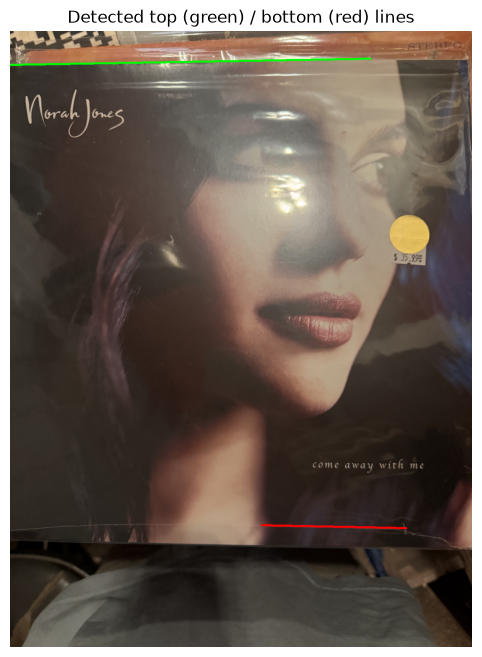

In [32]:
top_line, bottom_line = detect_top_bottom_lines(edges, bgr_array.shape)
visualize_lines(bgr_array, top_line, bottom_line)

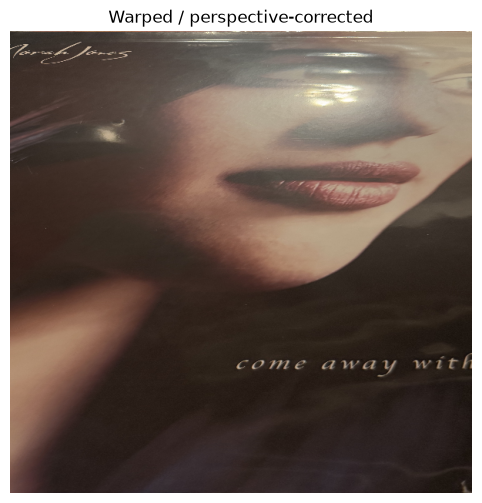

In [33]:
# on the downscaled image
top_line, bottom_line = detect_top_bottom_lines(edges, small.shape)
corners_small = resolve_corners(top_line, bottom_line, small.shape)

# map back up to full resolution
corners_full = rescale_corners(corners_small, scale_factor)

# warp against the ORIGINAL full-res image, using full-res corners
warped = warp_to_rectangle(bgr_array_original, corners_full)
visualize_warp(warped)

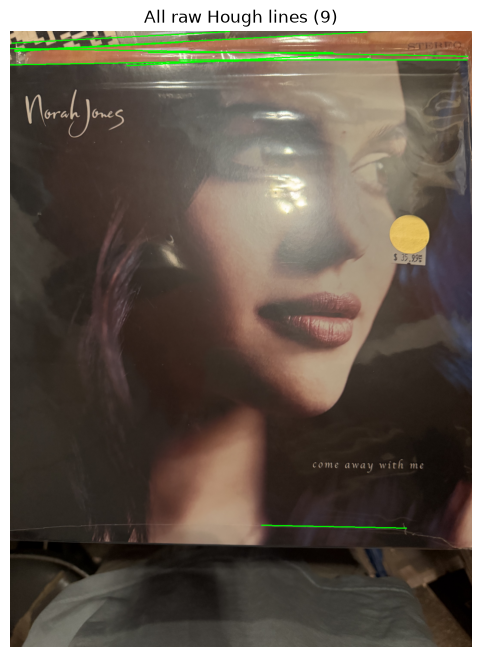

In [34]:
# Display every raw Hough line on the photo without changing the existing pipeline.
raw_lines = cv2.HoughLinesP(
    edges,
    rho=1,
    theta=np.pi / 180,
    threshold=150,
    minLineLength=bgr_array.shape[1] * 0.3,
    maxLineGap=200,
)

raw_lines_overlay = bgr_array.copy()
raw_line_count = 0 if raw_lines is None else len(raw_lines)

if raw_lines is not None:
    for raw_line in raw_lines:
        x1, y1, x2, y2 = raw_line
        cv2.line(raw_lines_overlay, (x1, y1), (x2, y2), (0, 255, 0), 2)
        raw_line_count += 0

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(raw_lines_overlay, cv2.COLOR_BGR2RGB))
plt.title(f"All raw Hough lines ({raw_line_count})")
plt.axis("off")
plt.show()

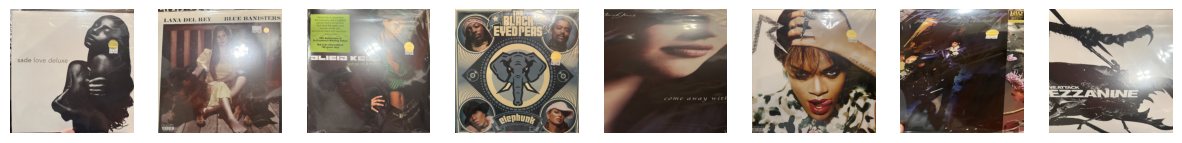

In [35]:
sample_files = [
    "Gold_Dots/Sade-LoveDeluxe.HEIC",
    "Gold_Dots/LanaDelRey-BlueBanisters.HEIC",
    "Gold_Dots/AliciaKeys-SongsInAMinor.HEIC",
    "Gold_Dots/TheBlackEyedPeas-Elephunk.HEIC",
    "Gold_Dots/NorahJones-ComeAwayWithMe.HEIC",
    "Gold_Dots/Rihanna-TalkThatTalk.HEIC",
    "Gold_Dots/Prince-PurpleRain.HEIC",
    "Gold_Dots/MassiveAttack-Mezzanine.HEIC",]

cropped_photos = []
for file in sample_files:
    image = Image.open(file)
    image = ImageOps.exif_transpose(image)  # Correct orientation based on EXIF data
    image = image.convert("RGB")

    rgb_array_full = np.array(image)
    bgr_array_full = rgb_array_full[..., ::-1]  # full-resolution, BGR

    # downscale before edge/line detection -- same reason as the single-image
    # pipeline above: full-res glare gaps blow past maxLineGap and break Hough
    file_scale_factor = 1500 / max(bgr_array_full.shape[:2])
    small = cv2.resize(bgr_array_full, None, fx=file_scale_factor, fy=file_scale_factor, interpolation=cv2.INTER_AREA)

    gray = cv2.cvtColor(small, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blurred, 40, 120)

    top_line, bottom_line = detect_top_bottom_lines(edges, small.shape)
    corners_small = resolve_corners(top_line, bottom_line, small.shape)

    if corners_small is None:
        print(f"Skipping {file}: couldn't detect both top and bottom edges")
        continue

    # map back up to full resolution, then warp against THIS file's full-res image
    corners_full = rescale_corners(corners_small, file_scale_factor)
    warped = warp_to_rectangle(bgr_array_full, corners_full)
    cropped_photos.append(warped)

fig, axes = plt.subplots(1, len(cropped_photos), figsize=(15, 5))
if len(cropped_photos) == 1:
    axes = [axes]
for ax, cropped in zip(axes, cropped_photos):
    ax.imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
    ax.axis("off")
plt.show()